In [2]:
from sklearn.preprocessing import Normalizer

feature_order = [
    # 'epoch', 'train_size',

    # old
    # 'loss_start', 'loss_mid',
    'loss_last_1', 'loss_last_2',
    # 'loss_growth', 'loss_stability',

    # gap
    # 'gap_last', 'gap_growth', 'gap_std',

    # global
    # 'best_loss',
    'epochs_since_best',
    'global_slope', 'global_curvature',
    # 'distance_from_best',

    # recent
    'recent_slope', 'recent_improvement',

    'acc_norm', 'distance_norm'
]

In [3]:
import pandas as pd
import numpy as np
import ast

from keras.src.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/final.csv", sep=';')

# строки -> списки
df['val_loss'] = df['val_loss'].map(ast.literal_eval)
df['train_loss'] = df['train_loss'].map(ast.literal_eval)

# flatten если вложенные списки
df['val_loss'] = df['val_loss'].map(lambda l: [v[0] if isinstance(v, list) else v for v in l])
df['train_loss'] = df['train_loss'].map(lambda l: [v[0] if isinstance(v, list) else v for v in l])

# фильтр
df = df[df['val_loss'].apply(lambda x: len(x) > 4)]
df = df[df['shift_type'].isin(['none', 'noise'])]
# -------- LOSS FEATURES --------

df["loss_start"] = df["val_loss"].apply(lambda x: x[0])
df["loss_mid"] = df["val_loss"].apply(lambda x: x[len(x) // 2])
df["loss_last_1"] = df["val_loss"].apply(lambda x: x[-2] / x[0])
df["loss_last_2"] = df["val_loss"].apply(lambda x: x[-3] / x[0])
df['acc_norm'] = df["val_loss"].apply(
    lambda c: ((c[-2] - c[-3]) - (c[-3] - c[-4])) / (c[-3] + 1e-8)
)
df["epoch"] = df["val_loss"].apply(len)
df["loss_end"] = df["val_loss"].apply(lambda x: x[-1])
df["loss_growth"] = df["loss_end"] - df["loss_start"]
df["loss_stability"] = df["val_loss"].apply(lambda x: np.std(x[:-1]))

df['distance_norm'] = df['val_loss'].apply(lambda x: (x[-2] - min(x[:-1])) / (x[0] - min(x[:-1]) + 1e-8))


# -------- GLOBAL CONTEXT FEATURES --------

def build_global_features(val_loss):
    val = np.array(val_loss)
    n = len(val)

    x = np.arange(n)

    # --- глобальный тренд ---
    slope = np.polyfit(x, val, 1)[0] if n > 1 else 0

    # --- кривизна (ускорение тренда) ---
    curvature = np.polyfit(x, val, 2)[0] if n > 2 else 0

    # --- лучший момент ---
    best_idx = np.argmin(val)
    best_loss = val[best_idx]

    # --- текущая позиция ---
    current_loss = val[-1]

    return pd.Series({
        "global_slope": slope,
        "global_curvature": curvature,

        "best_loss": best_loss,
        "distance_from_best": current_loss - best_loss,
        "epochs_since_best": n - best_idx,
    })


global_df = df["val_loss"].apply(build_global_features)
df = pd.concat([df, global_df], axis=1)


# -------- LOCAL (RECENT) FEATURES --------

def build_recent_features(val_loss, window=5):
    val = np.array(val_loss)
    n = len(val)

    if n < 2:
        return pd.Series({
            "recent_slope": 0,
            "recent_improvement": 0
        })

    val_recent = val[-window:] if n >= window else val
    x = np.arange(len(val_recent))

    slope = np.polyfit(x, val_recent, 1)[0] if len(val_recent) > 1 else 0

    improvement = val_recent[0] - val_recent[-1]

    return pd.Series({
        "recent_slope": slope,
        "recent_improvement": improvement
    })


recent_df = df["val_loss"].apply(build_recent_features)
df = pd.concat([df, recent_df], axis=1)

# -------- CLEAN --------
train_delta = (df["loss_end"] - df["loss_last_1"]) / df["loss_last_1"]
threshold = 0.5 * np.std(train_delta)
df['imbalance'] = df['imbalance'].astype(int)

# df = df.drop(columns=[
#     "val_loss",
#     "train_loss",
#     "val_acc",
#     "index",
#     "seed"
# ])

# -------- FEATURES --------

X = df[feature_order]
y = df["val_loss"].apply(lambda x: (x[-1] - x[-2]) / (x[-2] + 1e-8))
# y = y / np.std(y)
print(df.describe())
print(y.describe())
X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

             index        epoch     test_acc  overfitting   train_size  \
count  3696.000000  3696.000000  3696.000000  3696.000000  3696.000000   
mean   2098.242424    34.793290     0.753080     0.500000  1264.285714   
std    1202.835262    23.561086     0.156870     0.500068  1652.649140   
min       0.000000     6.000000     0.097500     0.000000    50.000000   
25%     993.250000    21.000000     0.639775     0.000000   100.000000   
50%    2211.500000    28.000000     0.769250     0.500000   500.000000   
75%    3135.250000    40.000000     0.889625     1.000000  2000.000000   
max    4059.000000   210.000000     0.982500     1.000000  5000.000000   

              seed    imbalance   loss_start     loss_mid  loss_last_1  ...  \
count  3696.000000  3696.000000  3696.000000  3696.000000  3696.000000  ...   
mean      6.106061     0.500000     1.600830     0.721397     0.430032  ...   
std       3.810903     0.500068     0.706650     0.507957     0.176769  ...   
min       0.00000

In [4]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# model = RandomForestRegressor(
#     n_estimators=300,
#     random_state=42,
#     n_jobs=-1
# )
model = XGBRegressor()

model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.019165702207436738
RMSE: 0.041345589388898596
R2: 0.30769462946235426


In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers

normalizer = layers.Normalization()
normalizer.adapt(X_train.to_numpy())
# --- модель ---
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # количество признаков
    normalizer,
    layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(32, activation='relu'),

    layers.Dense(1),
])

# --- компиляция ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=["mae"]
)

# --- обучение ---
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

# --- предсказание ---
pred = model.predict(X_test).flatten()

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Epoch 1/100


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.4862 - mae: 0.9286 - val_loss: 0.0665 - val_mae: 0.1504
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7560 - mae: 0.6612 - val_loss: 0.1053 - val_mae: 0.2106
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5129 - mae: 0.5379 - val_loss: 0.1205 - val_mae: 0.2204
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4180 - mae: 0.4801 - val_loss: 0.1210 - val_mae: 0.2152
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3509 - mae: 0.4419 - val_loss: 0.1162 - val_mae: 0.2132
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3295 - mae: 0.4249 - val_loss: 0.1005 - val_mae: 0.1988
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3024 - mae: 0.3985 - val_loss: 0.0962 - val_mae: 0.2023
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2688 - mae: 0.3835 - val_loss: 0.0885 - val_mae: 0.1959
Epoch 9/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2537 - mae: 0.3

In [6]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np


def benchmark_regressors(models, X_train, X_test, y_train, y_test):
    results = []

    for name, model in models.items():
        # обучение
        model.fit(X_train, y_train)

        # предсказание
        pred = model.predict(X_test)

        # метрики
        r2 = r2_score(y_test, pred)
        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))

        results.append({
            "model": name,
            "R2": r2,
            "MAE": mae,
            "RMSE": rmse,
            "mm": model
        })

    results_df = pd.DataFrame(results)
    return results_df.sort_values("R2", ascending=False)

In [7]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor
)

models = {

    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),

    "DecisionTree": DecisionTreeRegressor(),

    "RandomForest": RandomForestRegressor(n_estimators=200),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=200),

    "GradientBoosting": GradientBoostingRegressor(),
    "HistGradientBoosting": HistGradientBoostingRegressor(),

    "AdaBoost": AdaBoostRegressor(),

    "KNN": KNeighborsRegressor(n_neighbors=5),

    "SVR": SVR(),

    "MLP": MLPRegressor(max_iter=500)
}

results = benchmark_regressors(
    models,
    X_train,
    X_test,
    y_train,
    y_test
)

print(results)

model_reg = results.iloc[0]["mm"]

                   model            R2         MAE         RMSE  \
3           RandomForest  5.404859e-01    0.016972     0.033684   
6   HistGradientBoosting  5.141167e-01    0.018173     0.034637   
4             ExtraTrees  5.042209e-01    0.017377     0.034988   
5       GradientBoosting  4.904208e-01    0.019187     0.035472   
0       LinearRegression  3.827760e-01    0.020006     0.039039   
1                  Ridge  2.990964e-01    0.022280     0.041602   
8                    KNN  2.348410e-01    0.021686     0.043467   
2           DecisionTree  2.035803e-01    0.024603     0.044346   
9                    SVR -6.370319e-03    0.025348     0.049849   
7               AdaBoost -3.107771e-01    0.046096     0.056891   
10                   MLP -6.095363e+09  252.175808  3879.539027   

                                                   mm  
3   (DecisionTreeRegressor(max_features=1.0, rando...  
6                     HistGradientBoostingRegressor()  
4   (ExtraTreeRegressor(ran

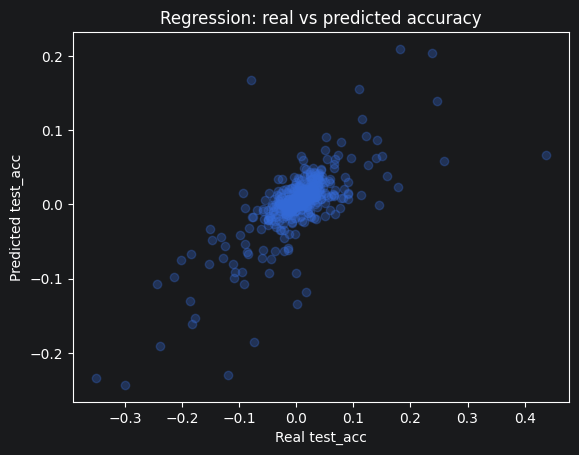

In [8]:
import matplotlib.pyplot as plt

pred = results.iloc[0]["mm"].predict(X_test)

plt.scatter(y_test, pred, alpha=0.3)

plt.xlabel("Real test_acc")
plt.ylabel("Predicted test_acc")
plt.title("Regression: real vs predicted accuracy")

# plt.plot([0,1],[0,1])
plt.show()


=== Результат предсказания следующего val_loss ===
MAE   = 0.01697
RMSE  = 0.03368
R²    = 0.5405   (54.05%)


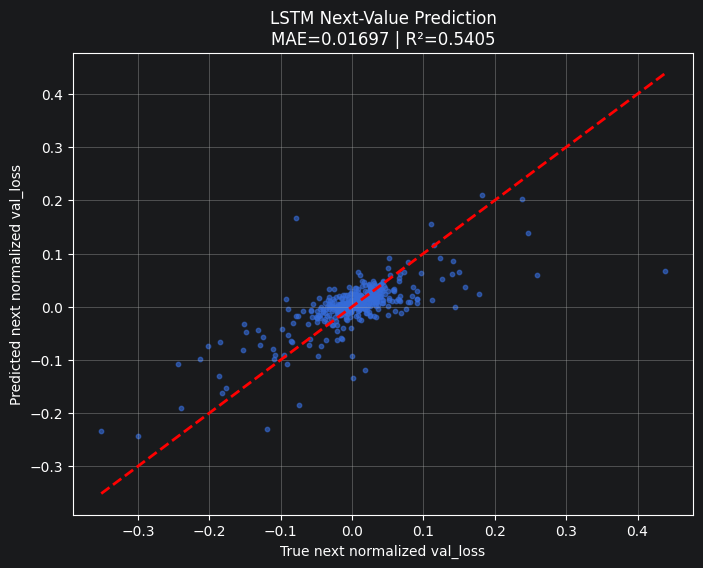

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ========================
# Создаём и обучаем модель
# ========================
# ========================
# Метрики
# ========================
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2  = r2_score(y_test, pred)

print("\n=== Результат предсказания следующего val_loss ===")
print(f"MAE   = {mae:.5f}")
print(f"RMSE  = {rmse:.5f}")
print(f"R²    = {r2:.4f}   ({r2*100:.2f}%)")

# ========================
# График True vs Predicted
# ========================
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred, alpha=0.6, s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("True next normalized val_loss")
plt.ylabel("Predicted next normalized val_loss")
plt.title(f"LSTM Next-Value Prediction\nMAE={mae:.5f} | R²={r2:.4f}")
plt.grid(True)
plt.show()

In [34]:
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import Callback

import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import Callback
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import Callback

class SmartEarlyStoppingMultiStep(Callback):
    def __init__(self,
                 model_meta,
                 train_size,
                 future_steps=5,      # увеличил до 4
                 min_epochs=8,
                 patience=1,
                 restore_best_weights=True):   # ← Новый параметр
        super().__init__()
        self.model_meta = model_meta
        self.train_size = train_size
        self.future_steps = future_steps
        self.min_epochs = min_epochs
        self.patience = patience
        self.restore_best_weights = restore_best_weights

        self.val_loss = []
        self.best_val_loss = np.inf
        self.best_weights = None
        self.best_epoch = 0
        self.counter = 0

    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get("val_loss")
        if val_loss is None:
            return

        self.val_loss.append(val_loss)

        # === Сохраняем лучшие веса ===
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.best_weights = self.model.get_weights()   # сохраняем веса
            self.best_epoch = epoch

        if len(self.val_loss) < self.min_epochs:
            return

        # Получаем прогноз
        preds = self.predict_future(epoch)

        current = self.val_loss[-1]
        future_min = min(preds)
        expected_improvement = current - future_min

        recent_std = np.std(self.val_loss[-8:]) if len(self.val_loss) >= 8 else 0.1

        # Более стабильное правило
        if expected_improvement < recent_std * 0.18:
            self.counter += 1
        else:
            self.counter = max(self.counter - 1, 0)

        print(f"epoch={epoch:3d} | val_loss={val_loss:.5f} | "
              f"future={[round(x,4) for x in preds]} | "
              f"improv={expected_improvement:.4f} | std={recent_std:.4f} | "
              f"counter={self.counter} | best={self.best_val_loss:.5f} (ep {self.best_epoch})")

        if self.counter >= self.patience:
            print(f"\n🔴 Expected future increase → stopping at epoch {epoch}")
            print(f"   Best val_loss = {self.best_val_loss:.5f} was at epoch {self.best_epoch}\n")

            # <<< ВОТ ГЛАВНОЕ ИСПРАВЛЕНИЕ >>>
            if self.restore_best_weights and self.best_weights is not None:
                print("→ Restoring best weights from epoch", self.best_epoch)
                self.model.set_weights(self.best_weights)

            self.model.stop_training = True

    def predict_future(self, epoch):
        val = list(self.val_loss)
        preds = []

        for step in range(self.future_steps):
            val_np = np.array(val)
            n = len(val_np)
            if n < 5:
                val_np = np.pad(val_np, (5 - n, 0), 'edge')

            x_full = np.arange(len(val_np))
            global_slope = np.polyfit(x_full, val_np, 1)[0] if len(val_np) > 1 else 0
            global_curvature = np.polyfit(x_full, val_np, 2)[0] if len(val_np) > 2 else 0
            best_idx = np.argmin(val_np)

            recent_window = 5
            val_recent = val_np[-recent_window:] if len(val_np) >= recent_window else val_np
            recent_slope = np.polyfit(np.arange(len(val_recent)), val_recent, 1)[0] if len(val_recent) > 1 else 0

            row = {
                "train_size": self.train_size,
                "epoch": epoch + step,
                "loss_start": val_np[0],
                "loss_mid": val_np[len(val_np)//2],
                "loss_last_1": val_np[-1] / val_np[0],
                "loss_last_2": val_np[-2] / val_np[0] if len(val_np) > 1 else 1.0,
                "global_slope": global_slope,
                "global_curvature": global_curvature,
                "epochs_since_best": len(val_np) - best_idx,
                "recent_slope": recent_slope,
                "recent_improvement": val_recent[0] - val_recent[-1] if len(val_recent) > 1 else 0,
                "acc_norm": (val_np[-1] - 2*val_np[-2] + val_np[-3]) / val_np[0] if len(val_np) > 2 else 0,
                "distance_norm": (val_np[-1] - min(val_np)) / (val_np[0] - min(val_np) + 1e-8),
            }

            df_row = pd.DataFrame([row])[feature_order]
            pred_delta = self.model_meta.predict(df_row)[0]
            next_val = val[-1] * (1 + pred_delta)
            preds.append(next_val)
            val.append(next_val)

        return preds

In [35]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)


def build_mlp_overfit():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),

        layers.Dense(32, activation="relu"),  # первый скрытый слой
        # layers.Dense(212, activation="relu"),     # второй скрытый слой
        # layers.Dense(256, activation="relu"),     # третий скрытый слой
        # Сильно уменьшаем Dropout или убираем его
        layers.Dropout(0.05),
        layers.Dense(10, activation="softmax")  # выходной слой
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [36]:
smart_stop = SmartEarlyStoppingMultiStep(
    model_reg,
    2000
)
model_mnist = build_mlp_overfit()
model_mnist.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_mnist.fit(
    X_train[:2000],
    y_train[:2000],

    validation_split=0.2,
    epochs=200,
    batch_size=10,
    # callbacks=[EarlyStopping(verbose=1, patience=5)]
    # callbacks=[smart_stop]

    callbacks=[smart_stop], verbose=0,
)



D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=  7 | val_loss=0.25004 | future=[np.float64(0.2471), np.float64(0.2441), np.float64(0.2425), np.float64(0.2392), np.float64(0.2381)] | improv=0.0119 | std=0.1343 | counter=1 | best=0.25004 (ep 7)

🔴 Expected future increase → stopping at epoch 7
   Best val_loss = 0.25004 was at epoch 7

→ Restoring best weights from epoch 7


In [37]:
from tensorflow.keras.callbacks import EarlyStopping


def run_training(X, y, train_size, callback, X_test_df, y_test_df, build_model):
    curr_model = build_model()
    history = curr_model.fit(
        X[:train_size],
        y[:train_size],
        validation_split=0.2,
        epochs=200,
        batch_size=16,
        verbose=0,
        callbacks=[callback]
    )

    epochs = len(history.history["loss"])

    # качество на тесте
    test_loss, test_acc = curr_model.evaluate(X_test_df, y_test_df, verbose=0)

    best_val_loss = min(history.history["val_loss"])

    return {
        "epochs": epochs,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "best_val_loss": best_val_loss
    }

In [38]:
def runner(sizes, X_train_df, y_train_Df, X_test_df, y_test_df, build_model):
    runs = 4

    results = []
    count = len(sizes) * runs
    for j, size in enumerate(sizes):

        for r in range(runs):
            print(j * runs + r, count, "*" * 20)
            early = EarlyStopping(
                monitor="val_loss",
                patience=5
            )

            smart = SmartEarlyStoppingMultiStep(
                model_reg,
                size
            )

            res_early = run_training(X_train_df, y_train_Df, size, early, X_test_df, y_test_df, build_model)
            res_smart = run_training(X_train_df, y_train_Df, size, smart, X_test_df, y_test_df, build_model)

            results.append({
                "train_size": size,
                "run": r,

                "early_epochs": res_early["epochs"],
                "early_acc": res_early["test_acc"],
                "early_loss": res_early["test_loss"],

                "smart_epochs": res_smart["epochs"],
                "smart_acc": res_smart["test_acc"],
                "smart_loss": res_smart["test_loss"],
            })

    dfl = pd.DataFrame(results)
    dfl['diff_epochs'] = dfl['early_epochs'] - dfl['smart_epochs']
    dfl['diff_loss'] = dfl['early_loss'] - dfl['smart_loss']
    dfl['diff_acc'] = dfl['early_acc'] - dfl['smart_acc']
    return dfl


In [44]:
def sum_df(df_curr):
    summary = df_curr.groupby("train_size").mean()

    print(summary[[
        "early_acc",
        "smart_acc",
        "early_loss",
        "smart_loss",
        "early_epochs",
        "smart_epochs", "diff_epochs", 'diff_acc', 'diff_loss'
    ]])
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 5))

    plt.plot(summary.index, summary["early_loss"], marker="o", label="EarlyStopping")
    plt.plot(summary.index, summary["smart_loss"], marker="o", label="SmartStop")

    plt.xlabel("train_size")
    plt.ylabel("test_accuracy")
    plt.title("Callback quality comparison")

    plt.legend()
    plt.grid()

    plt.show()
    summary.plot(kind="bar", figsize=(8, 5))

    plt.ylabel("epochs trained")
    plt.title("Epochs until stopping")
    plt.grid()

    plt.show()
    plt.figure(figsize=(8, 5))

    for size in sizes:
        subset = df_curr[df_curr["train_size"] == size]

        plt.scatter(
            subset["diff_epochs"],
            subset["diff_acc"],
            label=f"{size}"
        )

    plt.axhline(0, linestyle="--")
    plt.axvline(0, linestyle="--")
    plt.xlabel("epochs saved")
    plt.ylabel("accuracy diff (early - smart)")
    plt.title("Trade-off: speed vs accuracy")
    plt.legend(title="train_size")
    plt.grid()

    plt.show()
    import matplotlib.pyplot as plt

    plt.plot(summary.index, summary["early_epochs"], marker="o", label="EarlyStopping")
    plt.plot(summary.index, summary["smart_epochs"], marker="o", label="SmartStop")

    plt.xlabel("train size")
    plt.ylabel("epochs until stop")

    plt.legend()
    plt.grid()

    plt.show()
sizes = [50, 500, 1000, 2000, 5000]

In [40]:
df = runner(sizes, X_train, y_train, X_test, y_test, build_mlp_overfit)

0 16 ********************


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=  7 | val_loss=0.59154 | future=[np.float64(0.5781), np.float64(0.5644), np.float64(0.5505), np.float64(0.5421), np.float64(0.5361)] | improv=0.0555 | std=0.3511 | counter=1 | best=0.59154 (ep 7)

🔴 Expected future increase → stopping at epoch 7
   Best val_loss = 0.59154 was at epoch 7

→ Restoring best weights from epoch 7
1 16 ********************


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=  7 | val_loss=0.59835 | future=[np.float64(0.5852), np.float64(0.5713), np.float64(0.5575), np.float64(0.5476), np.float64(0.5399)] | improv=0.0585 | std=0.3519 | counter=1 | best=0.59835 (ep 7)

🔴 Expected future increase → stopping at epoch 7
   Best val_loss = 0.59835 was at epoch 7

→ Restoring best weights from epoch 7
2 16 ********************


...

epoch=  7 | val_loss=0.26993 | future=[np.float64(0.2682), np.float64(0.2657), np.float64(0.2645), np.float64(0.2639), np.float64(0.2635)] | improv=0.0064 | std=0.0629 | counter=1 | best=0.26993 (ep 7)

🔴 Expected future increase → stopping at epoch 7
   Best val_loss = 0.26993 was at epoch 7

→ Restoring best weights from epoch 7
14 16 ********************


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=  7 | val_loss=0.28507 | future=[np.float64(0.283), np.float64(0.2817), np.float64(0.2807), np.float64(0.2802), np.float64(0.2798)] | improv=0.0053 | std=0.0592 | counter=1 | best=0.28507 (ep 7)

🔴 Expected future increase → stopping at epoch 7
   Best val_loss = 0.28507 was at epoch 7

→ Restoring best weights from epoch 7
15 16 ********************


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=  7 | val_loss=0.28752 | future=[np.float64(0.2849), np.float64(0.284), np.float64(0.2826), np.float64(0.2821), np.float64(0.2817)] | improv=0.0059 | std=0.0716 | counter=1 | best=0.28752 (ep 7)

🔴 Expected future increase → stopping at epoch 7
   Best val_loss = 0.28752 was at epoch 7

→ Restoring best weights from epoch 7


            early_acc  smart_acc  early_loss  smart_loss  early_epochs  \
train_size                                                               
500          0.821925   0.790200    0.607290    0.681878         24.00   
1000         0.865700   0.860575    0.447170    0.466972         16.25   
2000         0.892025   0.886150    0.388366    0.386006         22.25   
5000         0.919650   0.917700    0.278672    0.276721         16.75   

            smart_epochs  diff_epochs  diff_acc  diff_loss  
train_size                                                  
500                  8.0        16.00  0.031725  -0.074588  
1000                 8.0         8.25  0.005125  -0.019802  
2000                 8.0        14.25  0.005875   0.002361  
5000                 8.0         8.75  0.001950   0.001951  


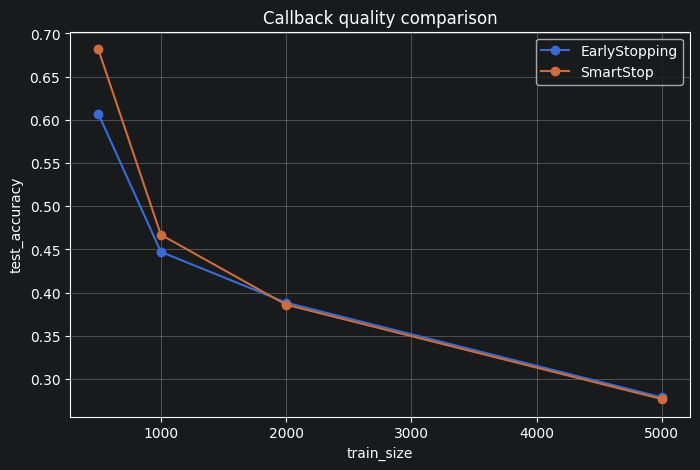

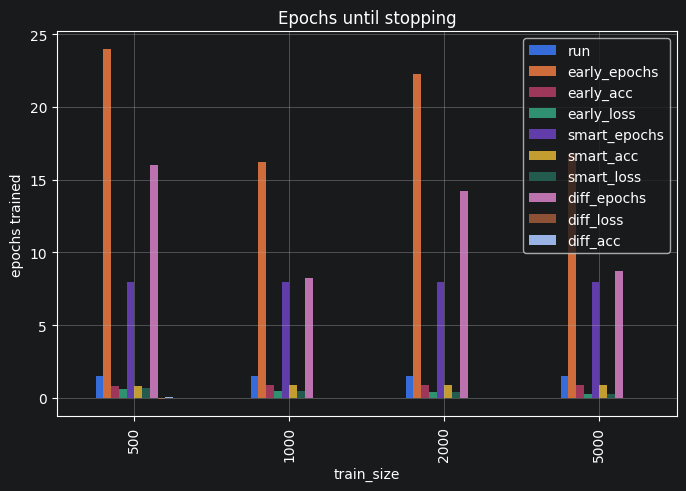

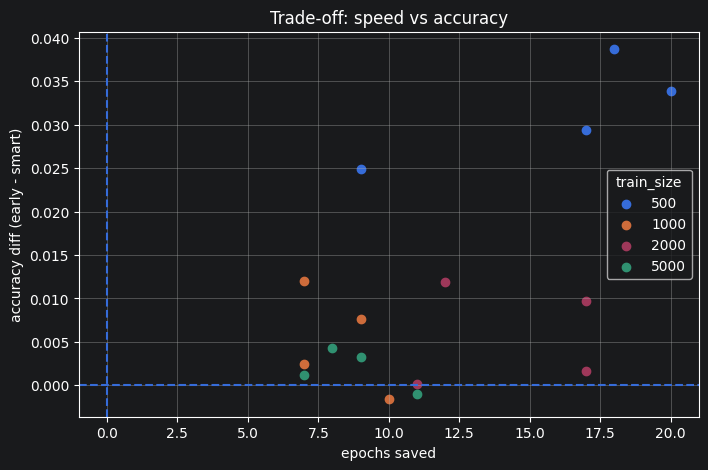

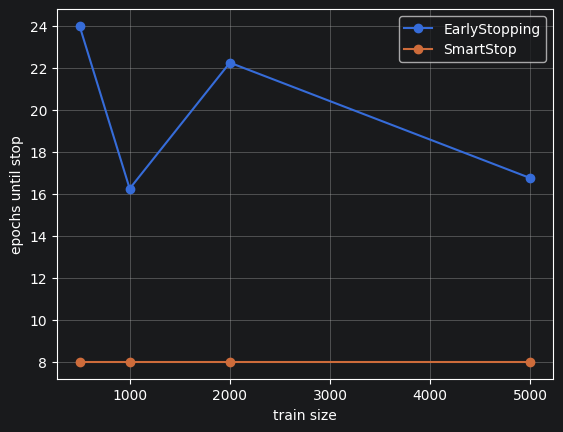

In [41]:
sum_df(df)

In [21]:
from pandas import read_csv, get_dummies
from sklearn.model_selection import train_test_split

df_student_med = read_csv('data/WineQT.csv')

X, Y = df_student_med[
    'fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol'.split(
        ',')
], df_student_med['quality']
X = get_dummies(X, drop_first=True)
from sklearn.preprocessing import Normalizer

normalizer = Normalizer()
X = normalizer.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


# print(y_test[:90])
def build_model_med():
    model = models.Sequential([
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


df_med = runner(sizes, X_train, y_train, X_test, y_test, build_model_med)

0 16 ********************
epoch=  9 | val_loss=1.26946 | future=[np.float64(1.2596), np.float64(1.2491), np.float64(1.2382), np.float64(1.2204)] | improv=0.0491 | std=0.0209 | counter=0 | best=1.26946 (ep 9)
epoch= 10 | val_loss=1.26800 | future=[np.float64(1.262), np.float64(1.2555), np.float64(1.2478), np.float64(1.2419)] | improv=0.0261 | std=0.0132 | counter=0 | best=1.26800 (ep 10)
epoch= 11 | val_loss=1.27776 | future=[np.float64(1.2836), np.float64(1.2891), np.float64(1.2937), np.float64(1.2987)] | improv=-0.0059 | std=0.0099 | counter=1 | best=1.26800 (ep 10)
epoch= 12 | val_loss=1.26933 | future=[np.float64(1.2691), np.float64(1.2707), np.float64(1.2796), np.float64(1.2807)] | improv=0.0003 | std=0.0088 | counter=2 | best=1.26800 (ep 10)
epoch= 13 | val_loss=1.26172 | future=[np.float64(1.2587), np.float64(1.255), np.float64(1.2502), np.float64(1.2439)] | improv=0.0178 | std=0.0082 | counter=1 | best=1.26172 (ep 13)
epoch= 14 | val_loss=1.26636 | future=[np.float64(1.2718), np

            early_acc  smart_acc  early_loss  smart_loss  early_epochs  \
train_size                                                               
500          0.557860   0.517467    1.078597    1.083697         32.25   
1000         0.538210   0.555677    1.058440    1.068675         34.50   
2000         0.529476   0.531659    1.057325    1.080545         36.75   
5000         0.512009   0.554585    1.063056    1.071044         34.00   

            smart_epochs  diff_epochs  diff_acc  diff_loss  
train_size                                                  
500                 27.0         5.25  0.040393  -0.005101  
1000                24.0        10.50 -0.017467  -0.010235  
2000                15.5        21.25 -0.002183  -0.023219  
5000                21.0        13.00 -0.042576  -0.007988  


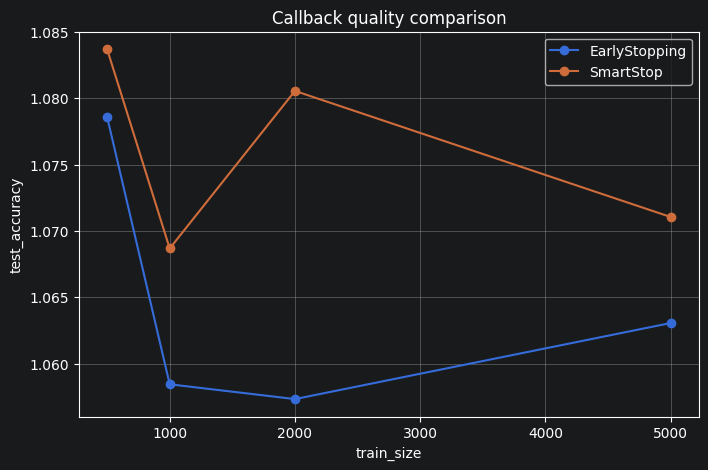

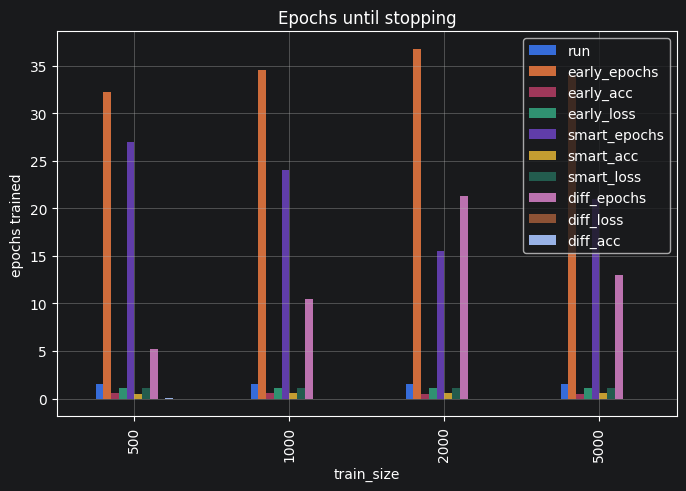

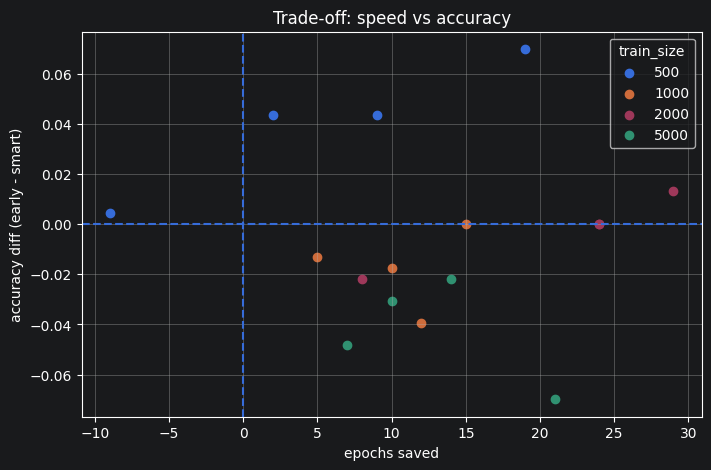

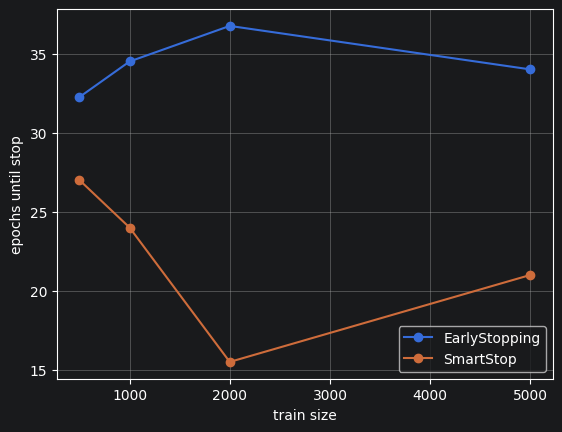

    train_size  run  early_epochs  early_acc  early_loss  smart_epochs  \
0          500    0            47   0.580786    1.070200            38   
1          500    1            35   0.563319    1.076442            16   
2          500    2            24   0.541485    1.088502            33   
3          500    3            23   0.545852    1.079243            21   
4         1000    0            30   0.545852    1.061274            20   
5         1000    1            33   0.532751    1.058528            18   
6         1000    2            47   0.528384    1.051463            35   
7         1000    3            28   0.545852    1.062494            23   
8         2000    0            47   0.532751    1.049824            18   
9         2000    1            40   0.545852    1.049995            16   
10        2000    2            38   0.558952    1.051975            14   
11        2000    3            22   0.480349    1.077507            14   
12        5000    0            39   0.

In [22]:
sum_df(df_med)
print(df_med.head(100))


In [42]:
import numpy as np
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

# ====================== ЗАГРУЗКА CIFAR-10 ======================
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

# Нормализация данных (приведение к диапазону [0, 1])
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Преобразование меток в одномерный массив (для sparse_categorical_crossentropy)
y_train_full = y_train_full.ravel()
y_test = y_test.ravel()

print(f"Полный размер обучающей выборки: {X_train_full.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

# ====================== ФУНКЦИЯ СОЗДАНИЯ МОДЕЛИ ======================
def build_model_cifar():
    model = models.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.1),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ====================== ЗАПУСК ЭКСПЕРИМЕНТА ======================
# Размеры обучающей выборки, которые будем тестировать

# Запуск сравнения EarlyStopping vs SmartEarlyStopping
df_cifar = runner(sizes, X_train_full, y_train_full, X_test, y_test, build_model_cifar)

D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Полный размер обучающей выборки: 50000
Размер тестовой выборки: 10000
0 16 ********************


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=  7 | val_loss=2.00727 | future=[np.float64(1.9688), np.float64(1.9379), np.float64(1.9029), np.float64(1.8651), np.float64(1.8353)] | improv=0.1719 | std=0.0675 | counter=0 | best=2.00727 (ep 7)
epoch=  8 | val_loss=2.03140 | future=[np.float64(1.8954), np.float64(1.8337), np.float64(1.7837), np.float64(1.7466), np.float64(1.7107)] | improv=0.3207 | std=0.0617 | counter=0 | best=2.00727 (ep 7)
epoch=  9 | val_loss=2.06845 | future=[np.float64(1.992), np.float64(1.9367), np.float64(1.9119), np.float64(1.8894), np.float64(1.8602)] | improv=0.2082 | std=0.0615 | counter=0 | best=2.00727 (ep 7)
epoch= 10 | val_loss=2.11498 | future=[np.float64(1.8842), np.float64(1.8476), np.float64(1.8248), np.float64(1.7998), np.float64(1.7637)] | improv=0.3513 | std=0.0617 | counter=0 | best=2.00727 (ep 7)
epoch= 11 | val_loss=1.95433 | future=[np.float64(1.9301), np.float64(1.9038), np.float64(1.8719), np.float64(1.8407), np.float64(1.8146)] | improv=0.1397 | std=0.0720 | counter=0 | best=1.9543

D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

epoch=  7 | val_loss=1.91686 | future=[np.float64(1.8114), np.float64(1.7585), np.float64(1.7353), np.float64(1.7117), np.float64(1.6819)] | improv=0.2350 | std=0.0693 | counter=0 | best=1.88842 (ep 6)
epoch=  8 | val_loss=1.88386 | future=[np.float64(1.8493), np.float64(1.8165), np.float64(1.7958), np.float64(1.772), np.float64(1.7485)] | improv=0.1354 | std=0.0536 | counter=0 | best=1.88386 (ep 8)
epoch=  9 | val_loss=1.89481 | future=[np.float64(1.8736), np.float64(1.8604), np.float64(1.8383), np.float64(1.8173), np.float64(1.7928)] | improv=0.1020 | std=0.0254 | counter=0 | best=1.88386 (ep 8)
epoch= 10 | val_loss=1.87797 | future=[np.float64(1.867), np.float64(1.8405), np.float64(1.8149), np.float64(1.7918), np.float64(1.7647)] | improv=0.1133 | std=0.0285 | counter=0 | best=1.87797 (ep 10)
epoch= 11 | val_loss=1.90558 | future=[np.float64(1.8392), np.float64(1.8203), np.float64(1.8025), np.float64(1.7788), np.float64(1.7542)] | improv=0.1514 | std=0.0258 | counter=0 | best=1.8779

D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=  7 | val_loss=1.87246 | future=[np.float64(1.9145), np.float64(1.8444), np.float64(1.8529), np.float64(1.8817), np.float64(1.875)] | improv=0.0280 | std=0.1056 | counter=0 | best=1.85964 (ep 5)
epoch=  8 | val_loss=1.85955 | future=[np.float64(1.8417), np.float64(1.8366), np.float64(1.8184), np.float64(1.803), np.float64(1.7878)] | improv=0.0718 | std=0.0454 | counter=0 | best=1.85955 (ep 8)
epoch=  9 | val_loss=1.87897 | future=[np.float64(2.0591), np.float64(2.2256), np.float64(2.3317), np.float64(2.4368), np.float64(2.6019)] | improv=-0.1801 | std=0.0340 | counter=1 | best=1.85955 (ep 8)

🔴 Expected future increase → stopping at epoch 9
   Best val_loss = 1.85955 was at epoch 8

→ Restoring best weights from epoch 8
15 16 ********************


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=  7 | val_loss=1.88735 | future=[np.float64(1.8576), np.float64(1.8363), np.float64(1.8112), np.float64(1.7858), np.float64(1.7632)] | improv=0.1241 | std=0.0649 | counter=0 | best=1.88735 (ep 7)
epoch=  8 | val_loss=1.90640 | future=[np.float64(1.8274), np.float64(1.7774), np.float64(1.758), np.float64(1.7377), np.float64(1.7117)] | improv=0.1947 | std=0.0404 | counter=0 | best=1.88735 (ep 7)
epoch=  9 | val_loss=1.89764 | future=[np.float64(1.8913), np.float64(1.8735), np.float64(1.8597), np.float64(1.837), np.float64(1.8152)] | improv=0.0825 | std=0.0229 | counter=0 | best=1.88735 (ep 7)
epoch= 10 | val_loss=1.90481 | future=[np.float64(1.8792), np.float64(1.8728), np.float64(1.8501), np.float64(1.827), np.float64(1.8016)] | improv=0.1033 | std=0.0190 | counter=0 | best=1.88735 (ep 7)
epoch= 11 | val_loss=1.89789 | future=[np.float64(1.9004), np.float64(1.895), np.float64(1.8933), np.float64(1.8993), np.float64(1.8987)] | improv=0.0046 | std=0.0121 | counter=0 | best=1.88735 (

    train_size  run  early_epochs  early_acc  early_loss  smart_epochs  \
0          500    0            15     0.2637    2.014972            13   
1          500    1            13     0.2470    2.075879            15   
2          500    2            15     0.2601    2.061128            10   
3          500    3            29     0.2693    2.060597             9   
4         1000    0            30     0.3026    1.933934            16   
5         1000    1            17     0.2603    2.055567             8   
6         1000    2            29     0.3050    1.947761            13   
7         1000    3            29     0.3056    1.941880            16   
8         2000    0            18     0.2998    1.900208            10   
9         2000    1            32     0.2975    1.951750            11   
10        2000    2            21     0.3164    1.896653            14   
11        2000    3            26     0.3061    1.906918            20   
12        5000    0            33     

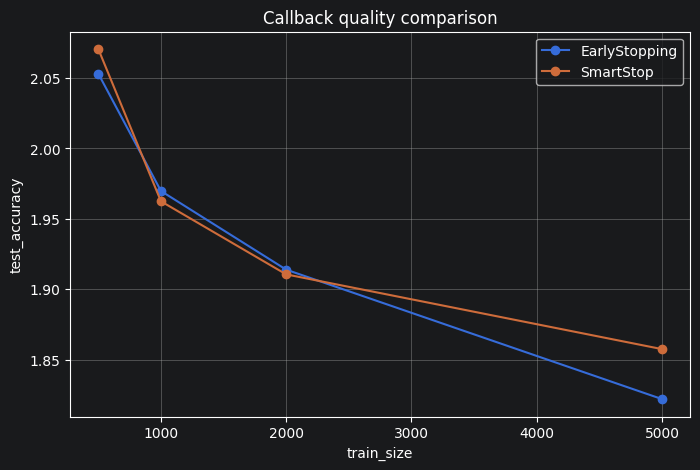

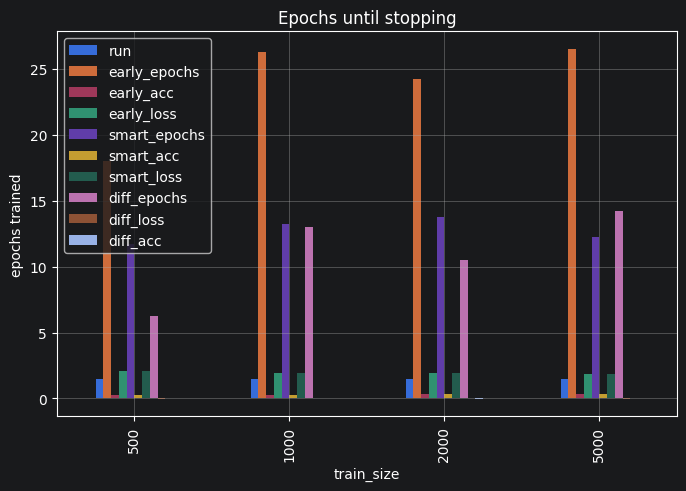

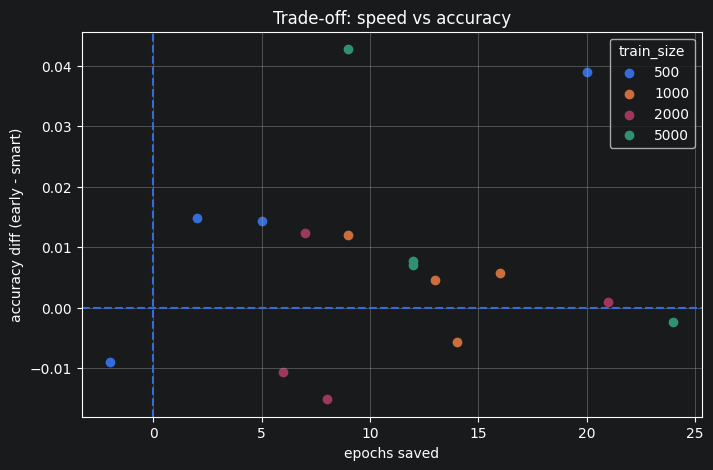

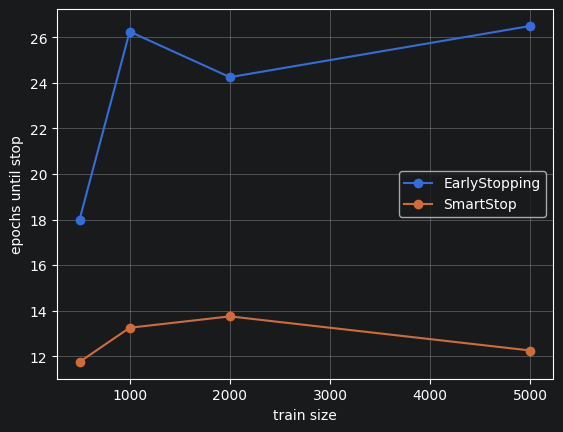

In [43]:
print(df_cifar.head(100))
sum_df(df_cifar)
